In [138]:
pip install torch torchvision matplotlib seaborn scikit-learn

In [139]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [140]:
# ── 1. DATASET ──────────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32,
                                           shuffle=True, num_workers=2)
testloader  = torch.utils.data.DataLoader(testset, batch_size=32,
                                           shuffle=False, num_workers=2)

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

In [141]:
# ── 2. MODEL ────────────────────────────────────────────────
model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)

# Freeze all backbone layers
for param in model.parameters():
    param.requires_grad = False

# Replace final FC layer for 10 classes
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 10)
)
model = model.to(DEVICE)


In [142]:
# ── 3. PRINT ARCHITECTURE ───────────────────────────────────
print("\n" + "="*60)
print("ResNet-152 Architecture Summary")
print("="*60)
print(model)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters   : {total_params - trainable_params:,}")



ResNet-152 Architecture Summary
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256

In [143]:
# ── 4. TRAINING ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

EPOCHS = 5
train_losses, train_accs = [], []

print("\n" + "="*60)
print("Training ResNet-152 (fine-tuning FC layer only)")
print("="*60)

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (i + 1) % 100 == 0:
            print(f"  Epoch [{epoch+1}/{EPOCHS}] Step [{i+1}/{len(trainloader)}] "
                  f"Loss: {running_loss/(i+1):.4f} | Acc: {100.*correct/total:.2f}%")

    epoch_loss = running_loss / len(trainloader)
    epoch_acc  = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    scheduler.step()
    print(f"\nEpoch {epoch+1} complete — Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%\n")



Training ResNet-152 (fine-tuning FC layer only)
  Epoch [1/5] Step [100/1563] Loss: 1.3672 | Acc: 53.06%
  Epoch [1/5] Step [200/1563] Loss: 1.1183 | Acc: 61.95%
  Epoch [1/5] Step [300/1563] Loss: 1.0055 | Acc: 65.81%
  Epoch [1/5] Step [400/1563] Loss: 0.9408 | Acc: 67.76%
  Epoch [1/5] Step [500/1563] Loss: 0.8979 | Acc: 69.16%
  Epoch [1/5] Step [600/1563] Loss: 0.8746 | Acc: 70.16%
  Epoch [1/5] Step [700/1563] Loss: 0.8539 | Acc: 70.76%
  Epoch [1/5] Step [800/1563] Loss: 0.8367 | Acc: 71.46%
  Epoch [1/5] Step [900/1563] Loss: 0.8227 | Acc: 71.97%
  Epoch [1/5] Step [1000/1563] Loss: 0.8107 | Acc: 72.40%
  Epoch [1/5] Step [1100/1563] Loss: 0.8023 | Acc: 72.61%
  Epoch [1/5] Step [1200/1563] Loss: 0.7944 | Acc: 72.82%
  Epoch [1/5] Step [1300/1563] Loss: 0.7867 | Acc: 73.13%
  Epoch [1/5] Step [1400/1563] Loss: 0.7759 | Acc: 73.50%
  Epoch [1/5] Step [1500/1563] Loss: 0.7690 | Acc: 73.69%

Epoch 1 complete — Loss: 0.7658 | Acc: 73.82%

  Epoch [2/5] Step [100/1563] Loss: 0.6073

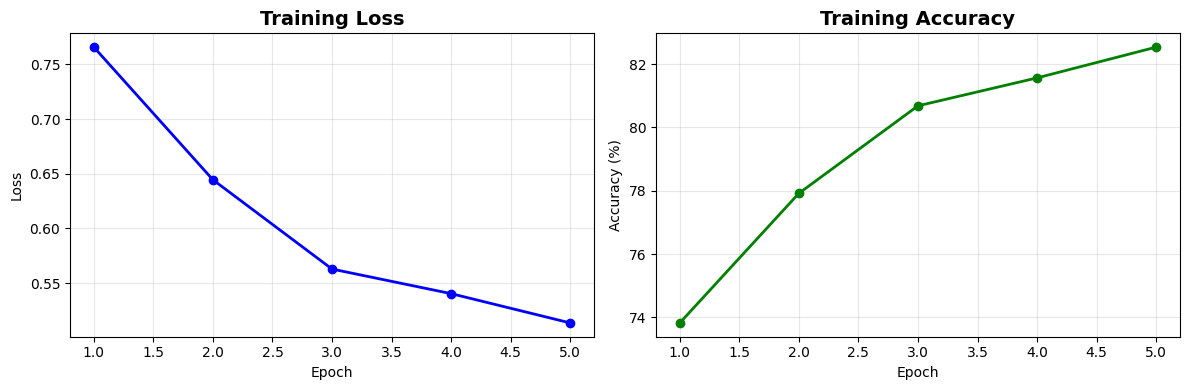

Saved: training_curves.png


In [144]:
# ── 5. PLOT TRAINING CURVES ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, EPOCHS+1), train_losses, 'b-o', linewidth=2, markersize=6)
ax1.set_title('Training Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, EPOCHS+1), train_accs, 'g-o', linewidth=2, markersize=6)
ax2.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")


Test Accuracy: 85.53%

Classification Report:
              precision    recall  f1-score   support

    airplane       0.88      0.83      0.85      1000
  automobile       0.86      0.93      0.90      1000
        bird       0.84      0.82      0.83      1000
         cat       0.76      0.76      0.76      1000
        deer       0.90      0.80      0.84      1000
         dog       0.78      0.89      0.83      1000
        frog       0.87      0.92      0.90      1000
       horse       0.90      0.84      0.87      1000
        ship       0.86      0.89      0.88      1000
       truck       0.92      0.87      0.89      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



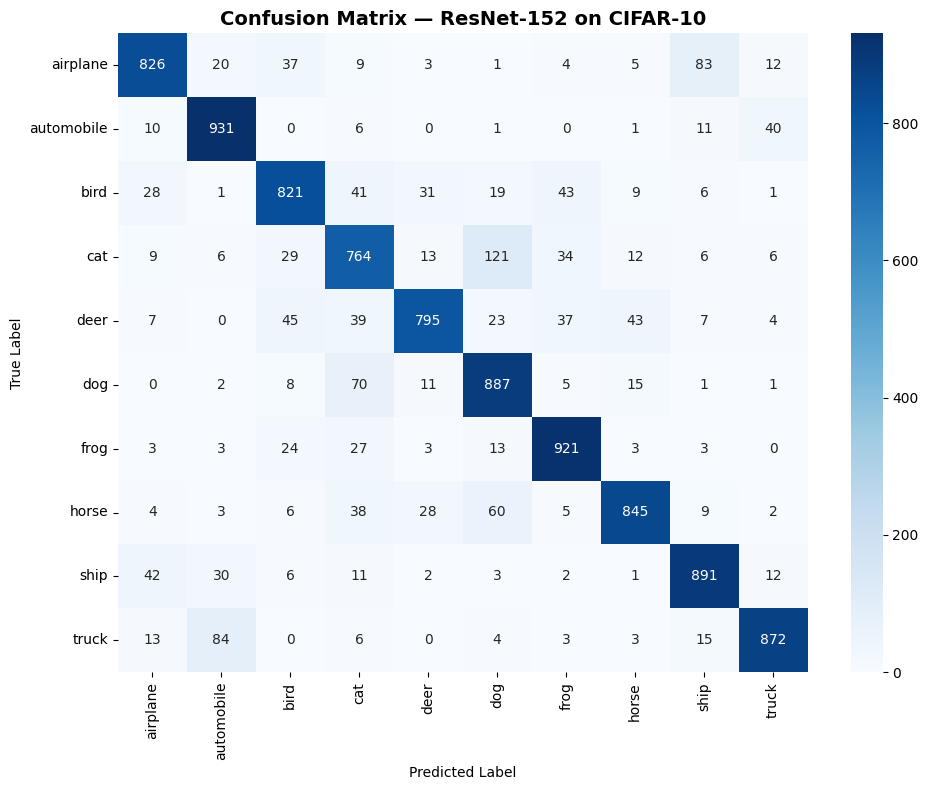

Saved: confusion_matrix.png


In [145]:
# ── 6. EVALUATION ───────────────────────────────────────────
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    correct, total = 0, 0
    for inputs, labels in testloader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100. * correct / total
print(f"\nTest Accuracy: {test_acc:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASSES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — ResNet-152 on CIFAR-10', fontsize=14, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")



Single Image Inference:
Target Class: cat
True label: cat

Top-5 Predictions:
  cat: 64.53%
  dog: 15.41%
  deer: 7.61%
  truck: 4.40%
  bird: 3.72%


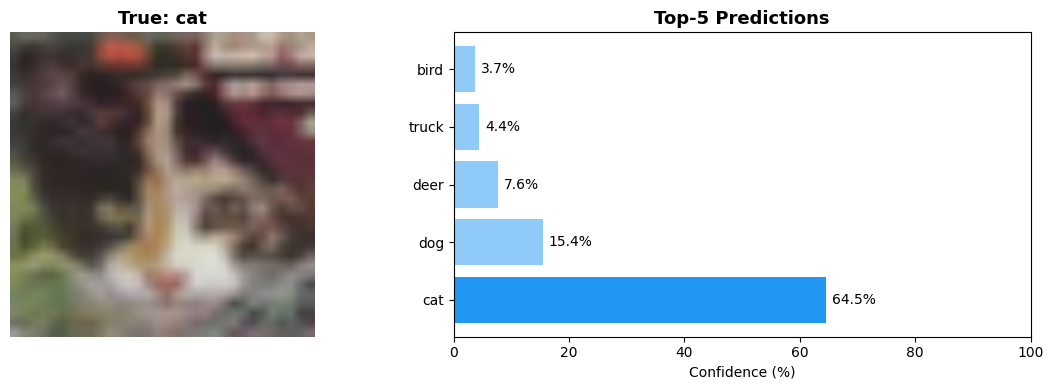

Saved: inference_result.png


In [146]:
# ── 7. SINGLE IMAGE INFERENCE (RANDOM CLASS IMAGE) ────────────
model.eval()

import random
import torch
import matplotlib.pyplot as plt
import numpy as np

# ── Choose class ──
target_class = "cat"

# ── Collect all images of that class ──
class_images = [(img, label) for img, label in testset if CLASSES[label] == target_class]

# ── Randomly select one image ──
sample_img, sample_label = random.choice(class_images)

# ── Prepare input ──
input_tensor = sample_img.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)[0]

    top5_prob, top5_idx = torch.topk(probabilities, 5)


top5_prob = top5_prob.cpu()
top5_idx = top5_idx.cpu()

# ── Print results ──
print(f"\nSingle Image Inference:")
print(f"Target Class: {target_class}")
print(f"True label: {CLASSES[sample_label]}")

print("\nTop-5 Predictions:")
for i in range(5):
    print(f"  {CLASSES[top5_idx[i]]}: {top5_prob[i]*100:.2f}%")

# ── Visualization ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

img_show = sample_img.permute(1, 2, 0).numpy()
img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img_show = np.clip(img_show, 0, 1)

ax1.imshow(img_show, interpolation='bicubic')
ax1.set_title(f"True: {CLASSES[sample_label]}", fontsize=13, fontweight='bold')
ax1.axis('off')

colors = ['#2196F3' if i == 0 else '#90CAF9' for i in range(5)]

bars = ax2.barh(
    [CLASSES[i] for i in top5_idx],
    [p.item() * 100 for p in top5_prob],
    color=colors
)

ax2.set_xlabel("Confidence (%)")
ax2.set_title("Top-5 Predictions", fontsize=13, fontweight='bold')
ax2.set_xlim(0, 100)

for bar, prob in zip(bars, top5_prob):
    ax2.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{prob.item() * 100:.1f}%",
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.savefig("inference_result.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: inference_result.png")

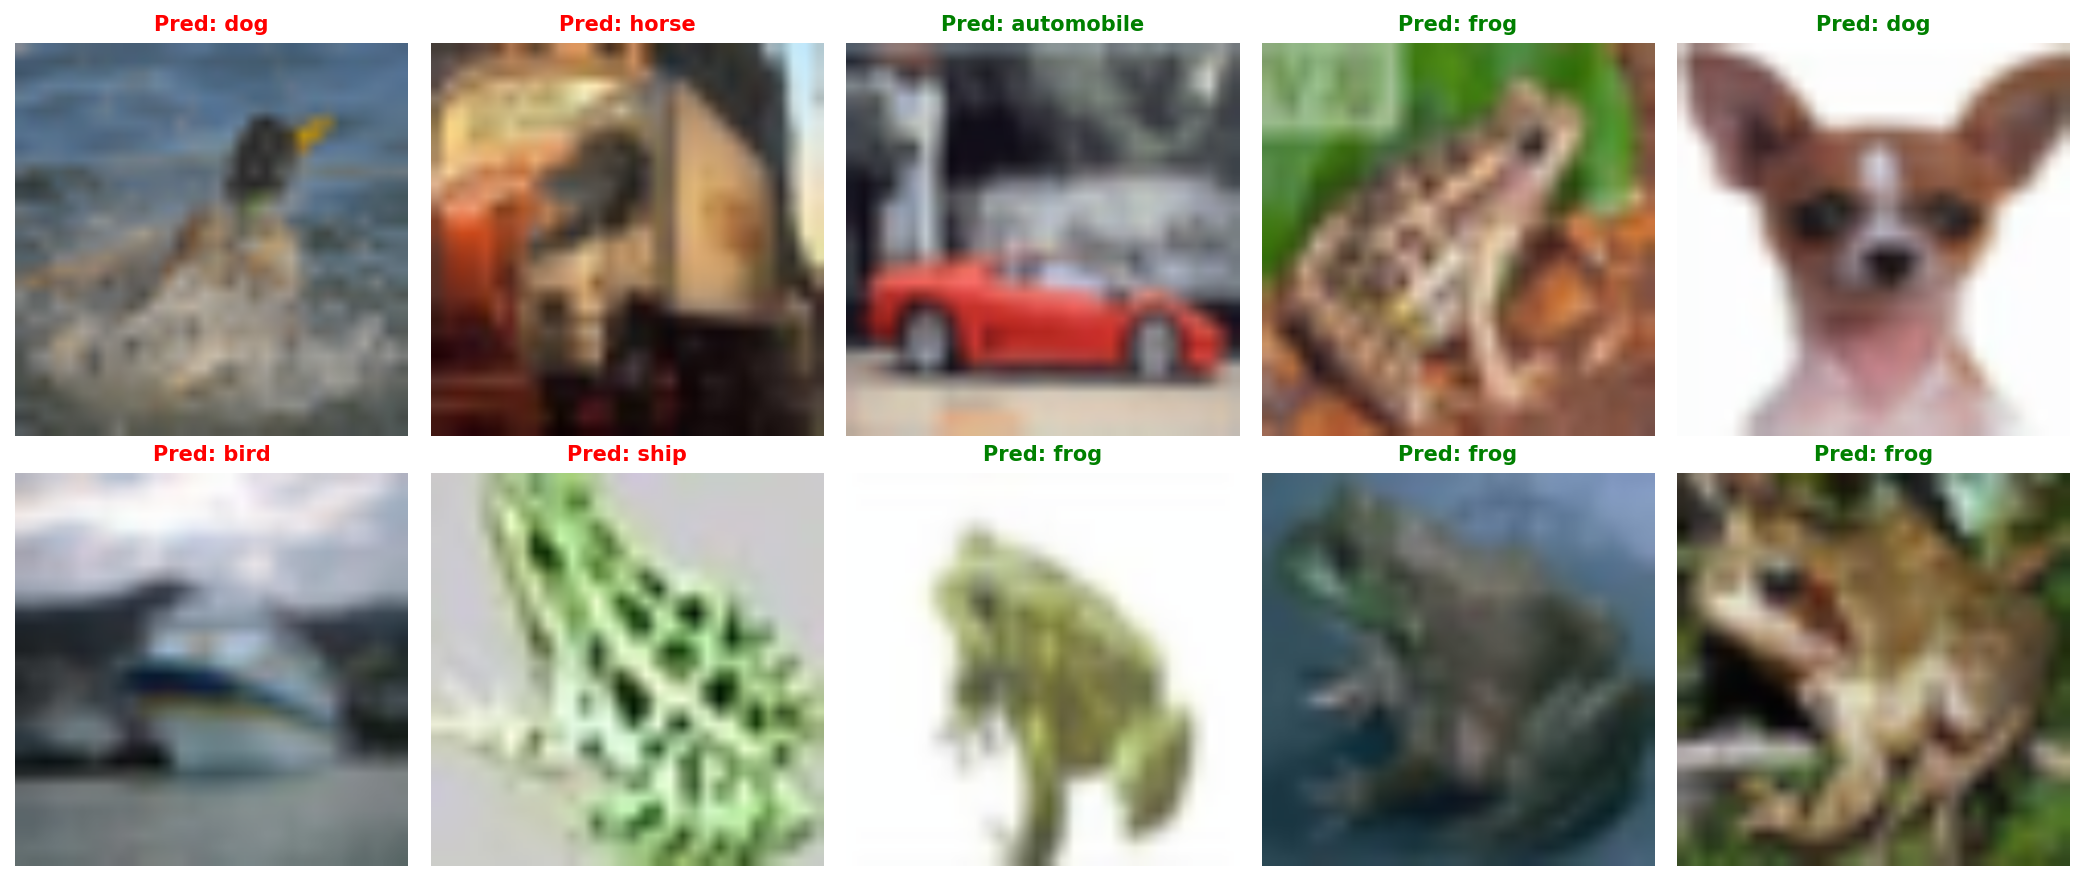

Saved: multi_10_random_predictions.png


In [147]:
# ── MULTI IMAGE INFERENCE (10 RANDOM IMAGES) ────────────────
model.eval()

import torch
import matplotlib.pyplot as plt
import numpy as np
import random

num_images = 10

# ── Select 10 random indices ──
random_indices = random.sample(range(len(testset)), num_images)

fig, axes = plt.subplots(2, 5, figsize=(14, 6), dpi=150)
axes = axes.flatten()

with torch.no_grad():
    for i, idx in enumerate(random_indices):

        # ── Get random image ──
        sample_img, sample_label = testset[idx]
        input_tensor = sample_img.unsqueeze(0).to(DEVICE)

        # ── Prediction ──
        output = model(input_tensor)
        _, pred = torch.max(output, 1)
        pred = pred.item()

        # ── Convert image ──
        img_show = sample_img.permute(1, 2, 0).numpy()
        img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_show = np.clip(img_show, 0, 1)

        # ── Show image ──
        axes[i].imshow(img_show, interpolation='bicubic')
        axes[i].axis('off')

        # ── Title ──
        color = "green" if pred == sample_label else "red"
        axes[i].set_title(
            f"Pred: {CLASSES[pred]}",
            fontsize=10,
            fontweight='bold',
            color=color
        )

plt.tight_layout()
plt.savefig("multi_10_random_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: multi_10_random_predictions.png")

In [148]:
from tensorflow.keras.applications import ResNet152

# Load model
model = ResNet152(weights='imagenet')

# Show architecture table
model.summary()

Model: "resnet152"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 60,419,944 (230.48 MB)

 Trainable params: 60,268,520 (229.91 MB)

 Non-trainable params: 151,424 (591.50 KB)